In [1]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('../../')

from src.preprocessing import compute_phases, split_trajectories, filter_trajectories
from src.viz import plot_trajectories
from src.io import load_dataframe, save_dataframe


In [14]:
Pfolder = "../../data/choano/raw/"
Fed = ["Fed"+str(i)+"_track" for i in range(1,4)]
Starve = ["Starve"+str(i)+"_track" for i in range(1,4)]
ext = ".csv"
column_names = pd.read_csv(Pfolder+Starve[0]+ext, nrows=0).columns
print(column_names)

Index(['LABEL', 'ID', 'TRACK_ID', 'QUALITY', 'POSITION_X', 'POSITION_Y',
       'POSITION_Z', 'POSITION_T', 'FRAME', 'RADIUS', 'VISIBILITY',
       'MANUAL_SPOT_COLOR', 'MEAN_INTENSITY_CH1', 'MEDIAN_INTENSITY_CH1',
       'MIN_INTENSITY_CH1', 'MAX_INTENSITY_CH1', 'TOTAL_INTENSITY_CH1',
       'STD_INTENSITY_CH1', 'CONTRAST_CH1', 'SNR_CH1', 'ELLIPSE_X0',
       'ELLIPSE_Y0', 'ELLIPSE_MAJOR', 'ELLIPSE_MINOR', 'ELLIPSE_THETA',
       'ELLIPSE_ASPECTRATIO', 'AREA', 'PERIMETER', 'CIRCULARITY', 'SOLIDITY',
       'SHAPE_INDEX'],
      dtype='object')


In [15]:
dfs = []
track_id_offset = 0
selected_columns = ["TRACK_ID", "FRAME", "POSITION_X", "POSITION_Y", "POSITION_Z"]

for fed in Fed:
    file_path = Pfolder + fed + ext
    # Read only the columns we want
    df_temp = pd.read_csv(file_path, skiprows=range(0, 4), names=column_names, usecols=selected_columns)
    # Shift TRACK_ID to make them unique
    df_temp["TRACK_ID"] += track_id_offset
    # Update offset for the next file
    track_id_offset = df_temp["TRACK_ID"].max() + 1
    dfs.append(df_temp)

# Concatenate all
df = pd.concat(dfs, ignore_index=True)

dfs_starve = list()
for starve in Starve:
    file_path = Pfolder + starve + ext
    # Read only the columns we want
    df_temp = pd.read_csv(file_path, skiprows=range(0, 4), names=column_names, usecols=selected_columns)
    # Shift TRACK_ID to make them unique
    df_temp["TRACK_ID"] += track_id_offset
    # Update offset for the next file
    track_id_offset = df_temp["TRACK_ID"].max() + 1
    dfs_starve.append(df_temp)
# Concatenate all
df_starve = pd.concat(dfs_starve, ignore_index=True)
print(df.head())
print(df_starve.head())

   TRACK_ID  POSITION_X   POSITION_Y  POSITION_Z  FRAME
0         0  258.859259  1178.192593         0.0    187
1         0  267.000000  1171.224806         0.0     67
2         0  264.134921  1183.301587         0.0    154
3         0  263.454545  1185.446970         0.0    165
4         0  257.432624  1183.709220         0.0    226
   TRACK_ID   POSITION_X   POSITION_Y  POSITION_Z  FRAME
0       375  1600.120805  1167.808725         0.0      8
1       375  1585.032573  1129.628664         0.0     72
2       375  1599.539735  1160.678808         0.0     21
3       375  1584.345277  1118.188925         0.0     95
4       375  1579.377850  1095.706840         0.0    138


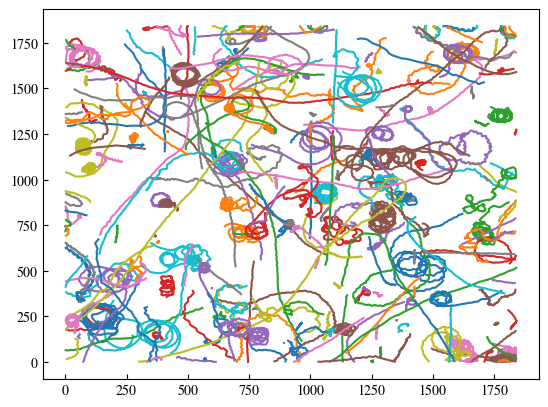

In [18]:
for i,traj in df.groupby('TRACK_ID'):
    traj = traj.sort_values('FRAME')
    plt.plot(traj['POSITION_X'],traj['POSITION_Y'])


In [ ]:
#df.to_parquet(Pfolder + 'fed_track.parquet',index = False)
#df_starve.to_parquet(Pfolder + 'track_track.parquet',index=False)

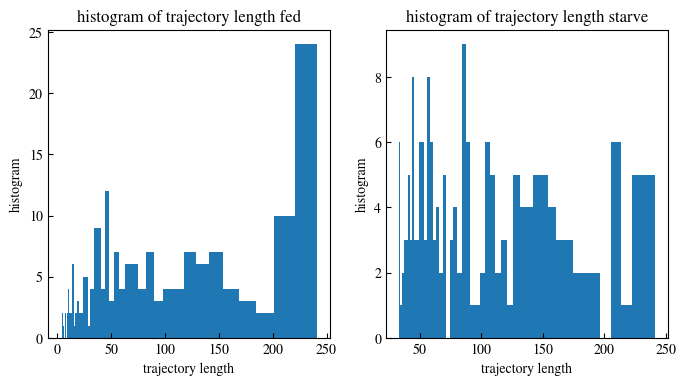

In [4]:
fig,ax = plt.subplots(ncols=2,figsize=(4*2,4))

SizeDistrib = df.groupby("TRACK_ID").size().values
bins = np.logspace(np.log10(np.min(SizeDistrib)),  # Start at min data value
                       np.log10(np.max(SizeDistrib)),  # End at max data value
                       50) 
ax[0].hist(SizeDistrib,bins=bins,log=False)

SizeDistrib = df_starve.groupby("TRACK_ID").size().values
bins = np.logspace(np.log10(np.min(SizeDistrib)),  # Start at min data value
                       np.log10(np.max(SizeDistrib)),  # End at max data value
                       50) 
ax[1].hist(SizeDistrib,bins=bins,log=False)

for i in range(2):
    ax[i].set_xlabel('trajectory length')
    ax[i].set_ylabel('histogram')
ax[0].set_title('histogram of trajectory length fed')
ax[1].set_title('histogram of trajectory length starve')
plt.show()

In [2]:
fed = load_dataframe('../../data/choano/interim/phases_fed_track.parquet')
fed.head()

,label,x,y,z,frame,speed,curvature_angle,torsion_angle,abs_torsion_angle
0,1,312.113412,1183.700080,0.0,1,0.671314,0.955576,0.0,0.0
1,1,311.523218,1183.742833,0.0,2,0.688669,0.113455,0.0,0.0
2,1,310.738284,1183.710520,0.0,3,0.943770,0.435941,0.0,0.0
3,1,309.721111,1184.134351,0.0,4,1.088750,2.469542,0.0,0.0
4,1,310.755595,1184.428747,0.0,5,1.770591,0.258953,0.0,0.0


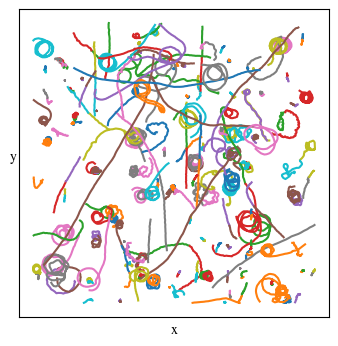

In [8]:
fig,ax = plt.subplots(figsize=(4,4))
for i,traj in fed.groupby("label"):
    traj = traj.sort_values('frame')
    ax.plot(traj['x'],traj['y'])

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlabel('x')
ax.set_ylabel('y',rotation=0)
fig.savefig('choano_trajectories.svg',bbox_inches='tight')